# Phase 4 - Part C: Fashion-MNIST **inverted** (full scale, SR-FCA only)

Rubric C (5%): apply the paper's method to a *different* heterogeneity source. We keep the same MLP and federated harness as notebook 01 but switch dataset and split: Fashion-MNIST + pixel inversion (K*=2, identity vs. invert). Same full-scale config (T=280, E=2, R=2). Tests whether SR-FCA's clustering primitive is source-of-heterogeneity agnostic.

### Outputs
- `results/part_c.csv`
- `results/figures/part_c_bar.png`, `results/figures/pairwise_hist_part_c.png`
- `results/cache/part_c_srfca_seed{seed}_T{T}_R{R}.pkl`


In [1]:
from __future__ import annotations

import pickle
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.datasets import make_mnist_federated
from src.federated import TrainConfig, local_train
from src.models import build_model
from src.metrics import misclustering_error
from src.srfca import SRFCAConfig, l2_pairwise, sr_fca
from src.utils import ensure_dir, get_device, set_seed

RESULTS_DIR = ensure_dir(ROOT / "results")
CACHE_DIR = ensure_dir(RESULTS_DIR / "cache")
FIG_DIR = ensure_dir(RESULTS_DIR / "figures")
DEVICE = get_device()

# Full-scale paper config.
TRAIN_CFG = TrainConfig(lr=0.01, local_epochs=2, batch_size=64, task="classification")
M_CLIENTS = 100
N_PER_CLIENT = 600
TEST_PER_CLIENT = 200
ROUNDS = 280
R_REFINE = 2
BETA = 0.1
T_MIN = 2
SEEDS = [0, 1, 2, 3, 4]
DATASET = "fashion_mnist"
SPLIT = "inverted"  # K*=2 (identity vs invert)
print("device:", DEVICE)


device: cpu


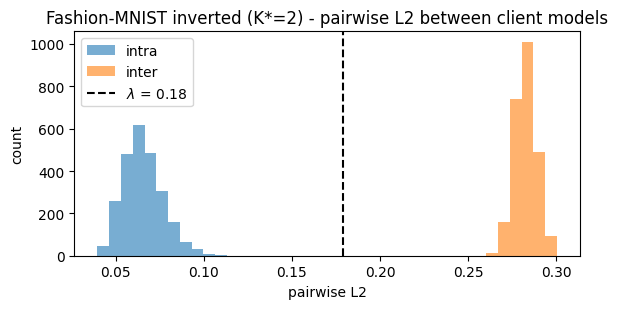

lambda for Fashion-MNIST inverted = 0.179


In [2]:
# Histogram + lambda.
set_seed(0)
fed0 = make_mnist_federated(split=SPLIT, m=M_CLIENTS, n_per_client=N_PER_CLIENT,
                            test_per_client=TEST_PER_CLIENT, seed=0, dataset=DATASET)
model = build_model(fed0).to(DEVICE)
init = model.flatten_weights().cpu()
flats = [local_train(model, c, TRAIN_CFG, DEVICE, init_flat=init) for c in fed0.clients]
D = l2_pairwise(flats)
labels = fed0.cluster_labels()
iu, ju = np.triu_indices(len(flats), k=1)
same = labels[iu] == labels[ju]
intra = D[iu[same], ju[same]]; inter = D[iu[~same], ju[~same]]
LAMBDA = float(0.5 * (np.percentile(intra, 95) + np.percentile(inter, 5)))

fig, ax = plt.subplots(figsize=(6, 3.2))
bins = np.linspace(D[iu, ju].min(), D[iu, ju].max(), 40)
ax.hist(intra, bins=bins, alpha=0.6, label="intra")
ax.hist(inter, bins=bins, alpha=0.6, label="inter")
ax.axvline(LAMBDA, color="k", linestyle="--", label=f"$\\lambda$ = {LAMBDA:.2f}")
ax.set_xlabel("pairwise L2"); ax.set_ylabel("count")
ax.set_title("Fashion-MNIST inverted (K*=2) - pairwise L2 between client models")
ax.legend(); fig.tight_layout()
fig.savefig(FIG_DIR / "pairwise_hist_part_c.png", dpi=120); plt.show()
print(f"lambda for Fashion-MNIST inverted = {LAMBDA:.3f}")


In [3]:
def evaluate_clustering(fed, clustering):
    model = build_model(fed).to(DEVICE)
    accs = []
    for i, c in enumerate(fed.clients):
        k = int(clustering.assignments[i])
        if k < 0 or k not in clustering.cluster_models:
            k = next(iter(clustering.cluster_models))
        model.load_flat_weights(clustering.cluster_models[k].to(DEVICE))
        model.eval()
        with torch.no_grad():
            accs.append(float((model(c.x_test.to(DEVICE)).argmax(-1) == c.y_test.to(DEVICE)).float().mean().item()))
    return {"test_acc_mean": float(np.mean(accs)),
            "test_acc_std": float(np.std(accs)),
            "misclustering": misclustering_error(fed.cluster_labels(), clustering.assignments),
            "k_found": int(clustering.n_clusters())}

def run_one(seed: int):
    cache_path = CACHE_DIR / f"part_c_srfca_seed{seed}_T{ROUNDS}_R{R_REFINE}.pkl"
    if cache_path.exists():
        with open(cache_path, "rb") as f:
            return pickle.load(f)
    set_seed(seed)
    fed = make_mnist_federated(split=SPLIT, m=M_CLIENTS, n_per_client=N_PER_CLIENT,
                               test_per_client=TEST_PER_CLIENT, seed=seed, dataset=DATASET)
    t0 = time.time()
    cfg = SRFCAConfig(lambda_=LAMBDA, t=T_MIN, beta=BETA, R=R_REFINE, rounds_per_refine=ROUNDS,
                      local_train_cfg=TRAIN_CFG, dist_mode="l2")
    clustering = sr_fca(fed, cfg, device=DEVICE, verbose=False)
    wall = time.time() - t0
    rec = {"method": "srfca", "seed": seed, "wall_sec": wall, **evaluate_clustering(fed, clustering)}
    with open(cache_path, "wb") as f:
        pickle.dump(rec, f)
    return rec

records = []
for seed in SEEDS:
    rec = run_one(seed)
    records.append(rec)
    print(f"[srfca s={seed}] acc={rec['test_acc_mean']:.3f} mis={rec['misclustering']:.3f} K={rec['k_found']} ({rec['wall_sec']/60:.1f} min)")
df = pd.DataFrame(records)
df.to_csv(RESULTS_DIR / "part_c.csv", index=False)
df.agg(acc_mean=("test_acc_mean", "mean"), acc_std=("test_acc_mean", "std"), mis_mean=("misclustering", "mean")).round(3)


[srfca s=0] acc=0.842 mis=0.000 K=2 (36.7 min)
[srfca s=1] acc=0.840 mis=0.000 K=2 (41.1 min)
[srfca s=2] acc=0.841 mis=0.000 K=2 (39.4 min)
[srfca s=3] acc=0.841 mis=0.000 K=2 (39.7 min)
[srfca s=4] acc=0.836 mis=0.000 K=2 (33.3 min)


,test_acc_mean,misclustering
acc_mean,0.840,NaN
acc_std,0.002,NaN
mis_mean,NaN,0.0


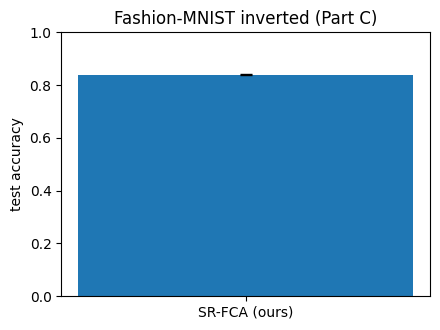

In [4]:
summary = df.agg({"test_acc_mean": ["mean", "std"], "misclustering": ["mean", "std"]})
fig, ax = plt.subplots(figsize=(4.5, 3.4))
ax.bar(["SR-FCA (ours)"], [summary.loc["mean", "test_acc_mean"]], yerr=[summary.loc["std", "test_acc_mean"]], capsize=4, color="C0")
ax.set_ylabel("test accuracy")
ax.set_title("Fashion-MNIST inverted (Part C)")
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(FIG_DIR / "part_c_bar.png", dpi=120)
plt.show()
